In [1]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.ticker import MultipleLocator, LogLocator
from src.dataset import CraneDataset
from tqdm.notebook import tqdm


In [2]:
file_name_list = ['data20251222-133102_swing_0_boom_55_1.csv',
                  'data20251222-133551_swing_0_boom_55_2.csv',
                  'data20251222-133904_swing_0_boom_55_3.csv',
                  'data20251222-134228_swing_0_boom_55_4.csv',
                  'data20251222-135532_swing_0_boom_45_1.csv',
                  'data20251222-135826_swing_0_boom_45_2.csv',
                  'data20251222-140154_swing_0_boom_45_3.csv',
                  'data20251222-140457_swing_0_boom_45_4.csv',
                  'data20251222-141357_swing_0_boom_35_1.csv',
                  'data20251222-141645_swing_0_boom_35_2.csv',
                  'data20251222-141951_swing_0_boom_35_3.csv',
                  'data20251222-142245_swing_0_boom_35_4.csv']

data_list = []

for file_name in file_name_list:
    path = os.path.join('data/on-road_test_15meter', file_name)
    data = pd.read_csv(path)
    data = data.iloc[:, 1:]
    data_list.append(data)

data = pd.concat(data_list, axis=0)

In [3]:
data_sorted = data.copy()
data_sorted = data_sorted[data_sorted['boom_angle(deg)'] > 20]
data_sorted.reset_index(drop=True, inplace=True)
data_sorted

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection
0,0.101,15.029,55.263,2.675,748.0,-0.598,5.625,-0.37,0.12,1.16,0.07,1.38,4.06,0.000,2.43,0.15611,0.0
1,0.201,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,1.15,0.07,1.38,4.06,0.000,2.43,0.15518,0.0
2,0.302,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,1.15,0.07,1.38,4.06,0.000,2.42,0.15646,0.0
3,0.402,15.030,55.268,2.681,748.0,-0.598,5.625,-0.37,0.11,1.16,0.07,1.38,4.06,0.000,2.42,0.15739,0.0
4,0.503,15.030,55.268,2.681,748.0,-0.598,5.625,-0.36,0.11,1.16,0.07,1.38,4.06,0.000,2.42,0.15739,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15355,123.615,15.025,35.070,3.709,748.0,-0.598,5.625,-0.35,0.38,1.19,0.04,2.23,8.68,23.344,1.44,0.45783,0.0
15356,123.716,15.025,35.070,3.709,748.0,-0.598,5.625,-0.35,0.38,1.19,0.04,2.23,8.68,23.344,1.44,0.45783,0.0
15357,123.817,15.025,35.070,3.709,748.0,-0.598,5.625,-0.35,0.38,1.19,0.04,2.23,8.68,23.344,1.44,0.45783,0.0
15358,123.917,15.021,35.058,3.678,748.0,-0.598,5.625,-0.34,0.38,1.19,0.04,2.23,8.68,23.344,1.44,0.45783,0.0


In [4]:
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
load_cell_name_list = np.array(load_cell_name_list)

In [5]:
from numpy.lib.stride_tricks import sliding_window_view

swing_0_data = data_sorted.copy()
len_window = 5

for load_cell_name in load_cell_name_list:
    load = data_sorted[load_cell_name].to_numpy()
    filtered_load = np.median(sliding_window_view(load, window_shape=len_window), axis=1)
    filtered_load = np.insert(filtered_load, 0, [0]*(len_window-1))
    swing_0_data[load_cell_name] = filtered_load

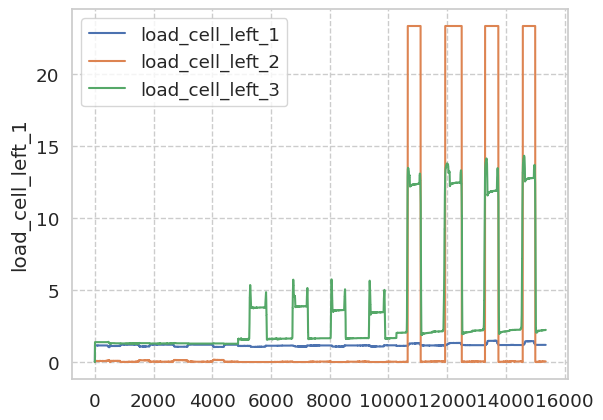

In [6]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

for load_cell_name in load_cell_name_list[0:3]:
    sns.lineplot(swing_0_data[load_cell_name], label=load_cell_name)

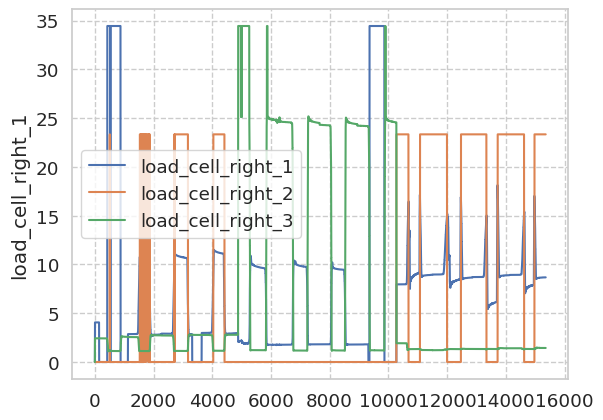

In [7]:
for load_cell_name in load_cell_name_list[3:6]:
    sns.lineplot(swing_0_data[load_cell_name], label=load_cell_name)

<Axes: ylabel='boom_angle(deg)'>

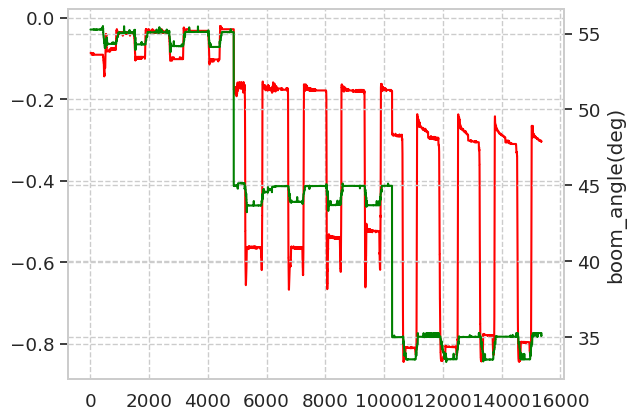

In [8]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

left_sum = swing_0_data[load_cell_name_list[0]] + swing_0_data[load_cell_name_list[2]]
left_1 = swing_0_data[load_cell_name_list[0]]/left_sum
left_2 = swing_0_data[load_cell_name_list[2]]/left_sum

left = left_1 - left_2

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(left, ax=ax1, color='red')
#sns.lineplot(data_1_sorted['load_weight(ton)'], color='green', ax=ax2)
sns.lineplot(swing_0_data['boom_angle(deg)'], color='green', ax=ax2)

<Axes: ylabel='boom_angle(deg)'>

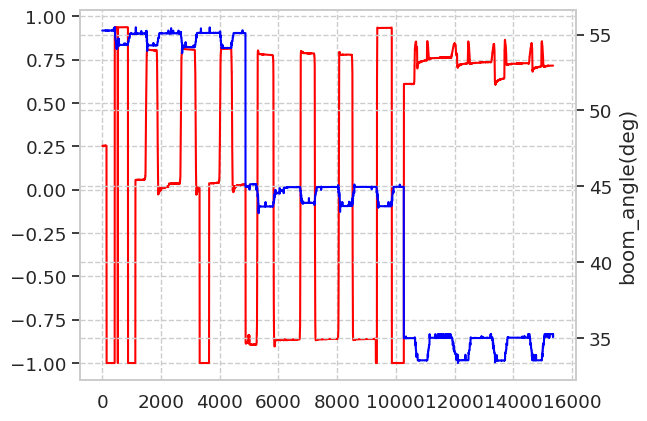

In [9]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

right_sum = swing_0_data[load_cell_name_list[3]] + swing_0_data[load_cell_name_list[5]]
right_1 = swing_0_data[load_cell_name_list[3]]/right_sum
right_2 = swing_0_data[load_cell_name_list[5]]/right_sum

right = right_1 - right_2

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(right, ax=ax1, color='red')
#sns.lineplot(data_1_sorted['load_weight(ton)'], color='green', ax=ax2)
sns.lineplot(swing_0_data['boom_angle(deg)'], color='blue', ax=ax2)

<Axes: ylabel='boom_angle(deg)'>

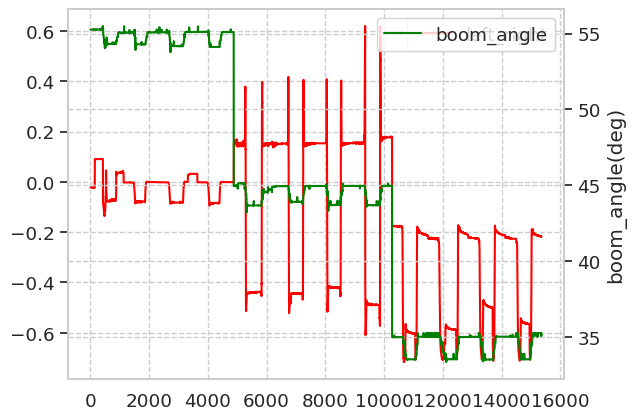

In [10]:
left_right = left*right

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(left_right, color='red', label='left_right', ax=ax1)
sns.lineplot(swing_0_data['boom_angle(deg)'], ax=ax2, color='green', label='boom_angle')

In [22]:
sns.scatterplot(x=new_data['boom_angle(deg)'], y=new_data['load_weight(ton)'], hue=roll_over_state, edgecolor='black')

NameError: name 'new_data' is not defined

In [18]:
file_name = 'data20251222-152557_swing_90_boom_55_2.csv'
#file_name = file_name_list[1]
path = os.path.join('data/on-road_test_15meter', file_name)
data = pd.read_csv(path)

load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
load_cell_name_list = np.array(load_cell_name_list)

In [19]:
data_sorted = data.copy()
data_sorted = data_sorted[data_sorted['boom_angle(deg)'] > 20]
data_sorted.reset_index(drop=True, inplace=True)
data_sorted

,Unnamed: 0,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection
0,0,0.202,15.009,55.198,2.831,748.0,-0.598,25.25,-0.14,0.69,8.38,0.12,2.05,1.38,0.0,1.01,0.52254,0.0
1,0,0.302,15.008,55.193,2.800,748.0,-0.598,25.25,-0.14,0.69,8.37,0.11,2.05,1.38,0.0,1.02,0.52098,0.0
2,0,0.403,15.006,55.188,2.800,748.0,-0.598,25.25,-0.14,0.69,8.38,0.12,2.05,1.37,0.0,1.02,0.52098,0.0
3,0,0.504,15.006,55.188,2.800,748.0,-0.598,25.25,-0.15,0.69,8.38,0.11,2.05,1.37,0.0,1.01,0.52217,0.0
4,0,0.604,15.006,55.188,2.806,748.0,-0.598,25.25,-0.15,0.69,8.37,0.11,2.05,1.37,0.0,1.01,0.52179,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1053,0,106.107,15.010,55.203,2.856,748.0,-0.598,25.25,-0.14,0.69,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0
1054,0,106.207,15.009,55.198,2.872,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0
1055,0,106.308,15.008,55.193,2.887,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0
1056,0,106.408,15.008,55.193,2.887,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0


Text(0.5, 0, 'Time(sec)')

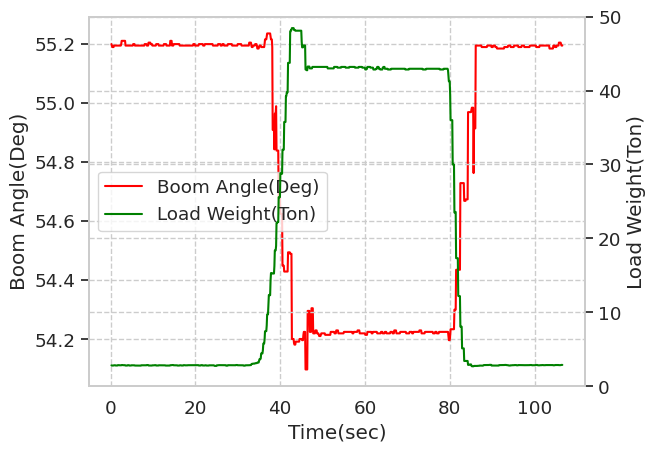

In [20]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(data=data_sorted, x='time(sec)', y='boom_angle(deg)', color='red', label='Boom Angle(Deg)', ax=ax1)
sns.lineplot(data=data_sorted, x='time(sec)', y='load_weight(ton)', color='green', label='Load Weight(Ton)', ax=ax2)


lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, [labels_1[0], labels_2[0]], loc='center left')
ax2.get_legend().remove() if ax2.get_legend() else None

ax1.set_ylabel(labels_1[0])
#ax1.set_ylim(43, 45)

ax2.set_ylabel(labels_2[0])
ax2.set_ylim(0, 50)

ax1.set_xlabel('Time(sec)')

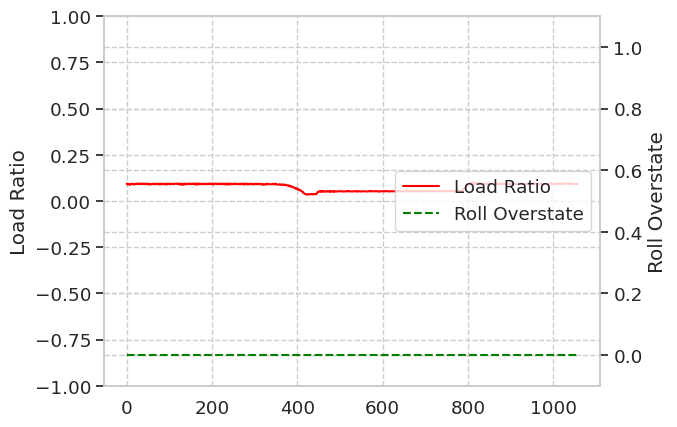

In [21]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

left_sum = data_sorted[load_cell_name_list[0]] + data_sorted[load_cell_name_list[2]]
left_1 = data_sorted[load_cell_name_list[0]]/left_sum
left_2 = data_sorted[load_cell_name_list[2]]/left_sum
left = left_1-left_2

right_sum = data_sorted[load_cell_name_list[3]] + data_sorted[load_cell_name_list[5]]
right_1 = data_sorted[load_cell_name_list[3]]/right_sum
right_2 = data_sorted[load_cell_name_list[5]]/right_sum
right = right_1 - right_2

left_right = left*right

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(left_right, color='red', label='Load Ratio', ax=ax1)
sns.lineplot(left_right < -0.6, color='green', linestyle='--', label='Roll Overstate', ax=ax2)

ax1.set_ylim(-1, 1)
ax1.set_ylabel('Load Ratio')
ax2.set_ylim(-0.1, 1.1)
ax2.set_ylabel('Roll Overstate')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, [labels_1[0], labels_2[0]], loc='center right')
ax2.get_legend().remove() if ax2.get_legend() else None

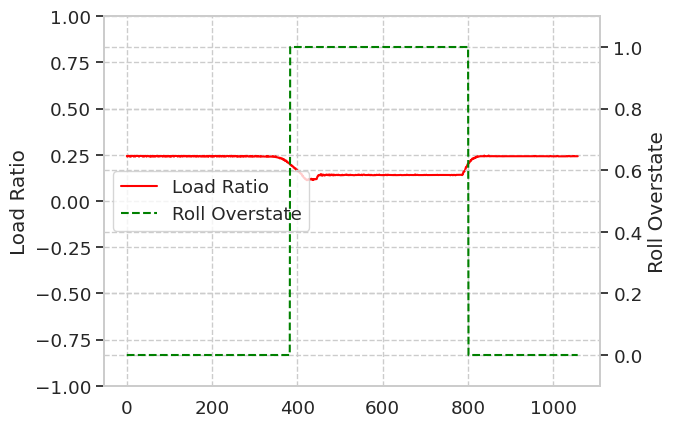

In [22]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

left_sum = data_sorted[load_cell_name_list[3]] + data_sorted[load_cell_name_list[0]]
left_1 = data_sorted[load_cell_name_list[3]]/left_sum
left_2 = data_sorted[load_cell_name_list[0]]/left_sum
left = left_1-left_2

right_sum = data_sorted[load_cell_name_list[5]] + data_sorted[load_cell_name_list[2]]
right_1 = data_sorted[load_cell_name_list[5]]/right_sum
right_2 = data_sorted[load_cell_name_list[2]]/right_sum
right = right_1 - right_2

load_ratio = left*right

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(load_ratio, color='red', label='Load Ratio', ax=ax1)
sns.lineplot(load_ratio < 0.2, color='green', linestyle='--', label='Roll Overstate', ax=ax2)

ax1.set_ylim(-1, 1)
ax1.set_ylabel('Load Ratio')
ax2.set_ylim(-0.1, 1.1)
ax2.set_ylabel('Roll Overstate')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, [labels_1[0], labels_2[0]], loc='center left')
ax2.get_legend().remove() if ax2.get_legend() else None

Text(0, 0.5, 'Load(Ton)')

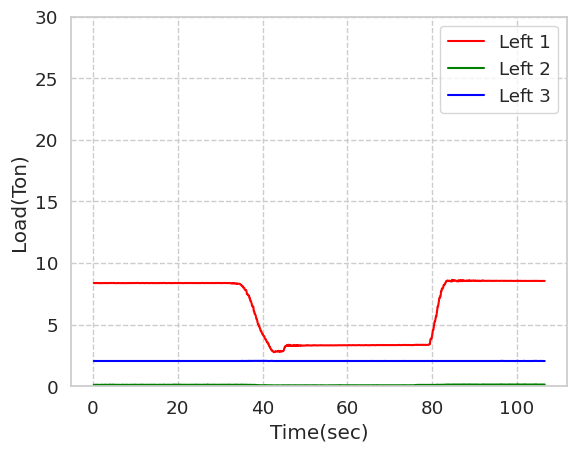

In [23]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

color_name_list = ['red', 'green', 'blue']
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3']
legend_name_list = ['Left 1', 'Left 2', 'Left 3']

for load_cell_name, color_name, legend_name in zip(load_cell_name_list, color_name_list, legend_name_list):
    sns.lineplot(data=data_sorted, x='time(sec)', y=load_cell_name, color=color_name, label=legend_name)

plt.xlabel('Time(sec)')

plt.ylim(0, 30)
plt.ylabel('Load(Ton)')

Text(0, 0.5, 'Load(Ton)')

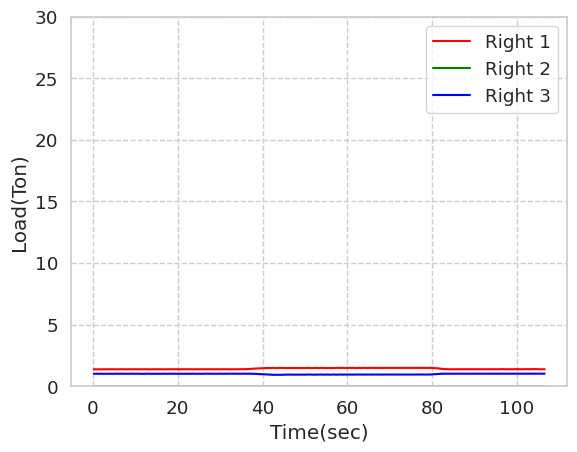

In [24]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

color_name_list = ['red', 'green', 'blue']
load_cell_name_list = ['load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
legend_name_list = ['Right 1', 'Right 2', 'Right 3']

for load_cell_name, color_name, legend_name in zip(load_cell_name_list, color_name_list, legend_name_list):
    sns.lineplot(data=data_sorted, x='time(sec)', y=load_cell_name, color=color_name, label=legend_name)

plt.xlabel('Time(sec)')

plt.ylim(0, 30)
plt.ylabel('Load(Ton)')